In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/romanised-hindi-and-english-text/Sheet 2-ENGLISH.csv
/kaggle/input/romanised-hindi-and-english-text/Sheet 1-ROMAN HINDI.csv


# LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import joblib



# Loading data

In [3]:
df_hindi_new = pd.read_csv("/kaggle/input/romanised-hindi-and-english-text/Sheet 1-ROMAN HINDI.csv")
df_english_new = pd.read_csv("/kaggle/input/romanised-hindi-and-english-text/Sheet 2-ENGLISH.csv")

# Labelling romanized hindi dataframe

In [4]:
df_hindi = df_hindi_new[['RAW']].copy()
df_hindi.columns = ['Text']
df_hindi['Language'] = 'Hindi_Roman'

# Labelling english dataframe

In [5]:
df_english = df_english_new[['LANGUAGE']].copy()
df_english.columns = ['Text']
df_english['Language'] = 'English'

# Remove the NaN value if present in english dataset 

In [6]:
df_english = df_english.dropna(subset=['Text'])

# Concatenate and shuffle the dataset

In [7]:
df_final = pd.concat([df_hindi, df_english], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Model setup and training

In [8]:
X=df_final['Text']
y=df_final['Language']

X_train, X_test,y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42, stratify=y
)

text_clf = Pipeline([
    ('tfidf',TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2,5)
    )),
    ('clf',LogisticRegression(
        solver='liblinear',
        random_state=42
    )),
])


# Model fit

In [9]:
text_clf.fit(X_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5))),
                ('clf',
                 LogisticRegression(random_state=42, solver='liblinear'))])

# Prediction and evaluation

In [10]:
y_pred=text_clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

     English       1.00      1.00      1.00      2922
 Hindi_Roman       1.00      1.00      1.00      2923

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



# VISUALIZATION

data distribution

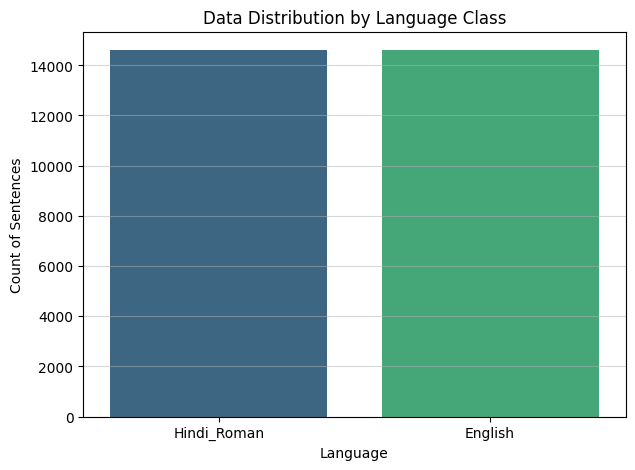

In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Language', data=df_final, palette='viridis')
plt.title('Data Distribution by Language Class')
plt.xlabel('Language')
plt.ylabel('Count of Sentences')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', alpha=0.5)
plt.show()

# CONFUSION MATRIX PLOT

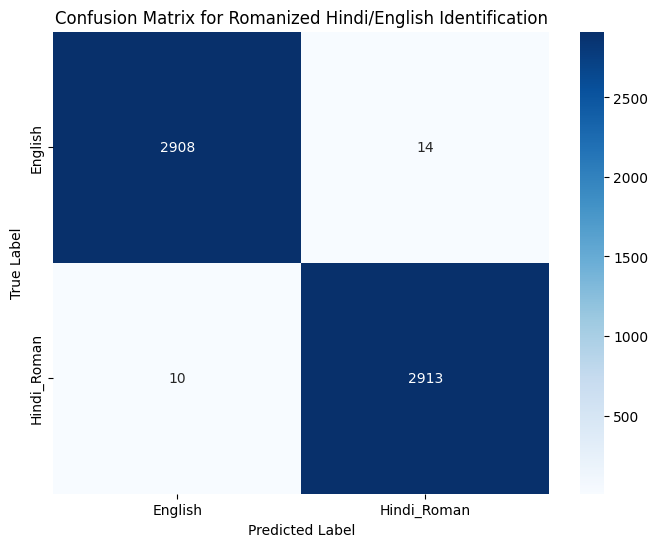

In [12]:
cm = confusion_matrix(y_test, y_pred)
labels = text_clf.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)
plt.title('Confusion Matrix for Romanized Hindi/English Identification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance Plot

feature name and model coefficients extraction clf(classifier) is at index 1 and tfidf is at index 0

In [13]:
coefs = text_clf.named_steps['clf'].coef_[0]
feature_names = text_clf.named_steps['tfidf'].get_feature_names_out()

a dataframe created to hold the features

In [14]:
feature_weights = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefs
})

top 10 features for each class
features with highest positive weight (hindi roman)
feature with most negative weight (english)

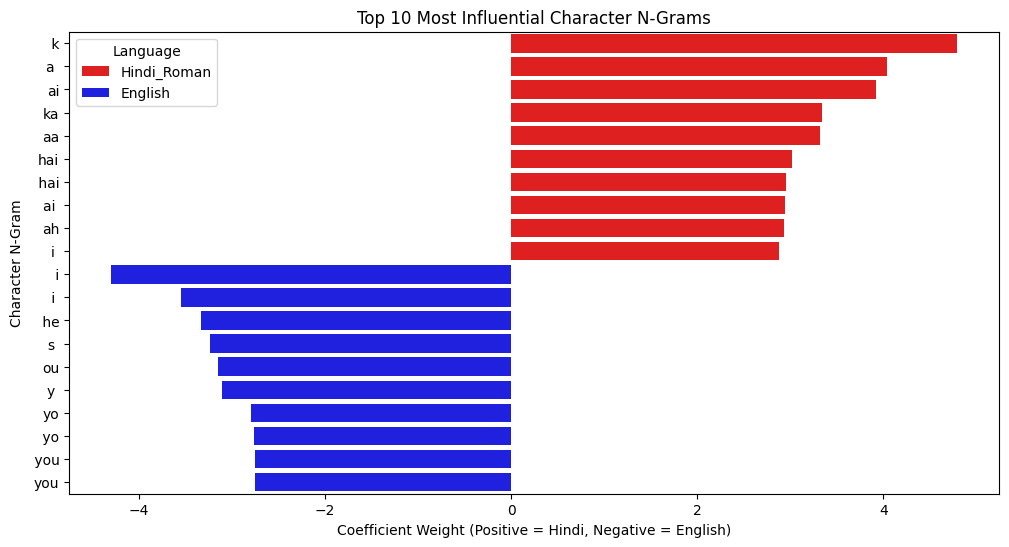

In [15]:
N = 10
top_hindi_features = feature_weights.sort_values(by='Weight', ascending=False).head(N)
top_english_features = feature_weights.sort_values(by='Weight', ascending=True).head(N)
plot_data = pd.concat([top_hindi_features, top_english_features])
plot_data['Language'] = np.where(plot_data['Weight'] > 0, 'Hindi_Roman', 'English')

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Weight', 
    y='Feature', 
    hue='Language', 
    data=plot_data, 
    dodge=False,
    palette={'Hindi_Roman': 'red', 'English': 'blue'}
)
plt.title(f'Top {N} Most Influential Character N-Grams')
plt.xlabel('Coefficient Weight (Positive = Hindi, Negative = English)')
plt.ylabel('Character N-Gram')
plt.show()

# Saving model for later use

In [16]:
joblib.dump(text_clf, 'hindi_english_lid_model.joblib')
print("\nModel saved successfully as: hindi_english_lid_model.joblib")


Model saved successfully as: hindi_english_lid_model.joblib


# Model deployment

In [17]:
import joblib
import os
import pandas as pd                                                                               # Needed to ensure consistency, though not strictly for prediction
MODEL_PATH = 'hindi_english_lid_model.joblib'
try:
    LANGUAGE_IDENTIFIER = joblib.load(MODEL_PATH)
    print("Model loaded successfully. Ready for deployment.")
except FileNotFoundError:
    print(f"ERROR: Model file not found at {MODEL_PATH}")
def predict_language(text: str) -> str:
    """Takes a Roman script string and predicts the language (English or Hindi_Roman)."""
    if not text or not isinstance(text, str):
        return "Invalid Input"
    prediction = LANGUAGE_IDENTIFIER.predict([text])[0]
    
    return prediction

Model loaded successfully. Ready for deployment.


# Example Test

In [18]:

test_sentence = "Would you like to have tea or coffee."
result = predict_language(test_sentence)

print(f"\nTest Sentence: '{test_sentence}'")
print(f"Prediction: {result}")


Test Sentence: 'Would you like to have tea or coffee.'
Prediction: English
